System has 2 CPU cores.
Testing T = 1 to 4 threads.
Matrix size: 500×500  |  Count: 500

T= 1 threads ... 6.02s
T= 2 threads ... 3.42s
T= 3 threads ... 4.69s
T= 4 threads ... 3.07s

────────────────────────────────────────────────────────────
Threads     T=1  T=2  T=3  T=4
Time (sec)   6.0   3.4   4.7   3.1
────────────────────────────────────────────────────────────

Best: T=4 threads → 3.07s
Speedup vs T=1: 1.96×

Results saved to results.csv


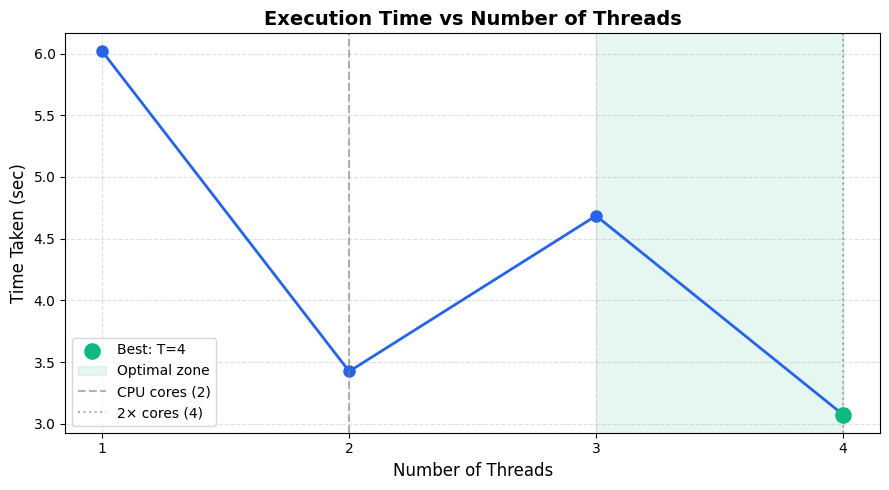

Graph saved to execution_time.png


In [1]:
"""
Assignment: Multi-Threading Matrix Multiplication
Strategy: Multiply matrices ONE AT A TIME (never store all 500 in RAM).
This keeps memory under ~200 MB regardless of matrix size.
"""

import numpy as np
import threading
import time
import os
import csv
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Configuration ──────────────────────────────────────────────────────────────
MATRIX_SIZE  = 500    # 500×500 = 1 MB per matrix — safe for Colab
                      # Bump to 1000 if you want heavier load (4 MB each)
NUM_MATRICES = 500
NUM_CORES    = os.cpu_count()
MAX_THREADS  = 2 * NUM_CORES
# ───────────────────────────────────────────────────────────────────────────────

print(f"System has {NUM_CORES} CPU cores.")
print(f"Testing T = 1 to {MAX_THREADS} threads.")
print(f"Matrix size: {MATRIX_SIZE}×{MATRIX_SIZE}  |  Count: {NUM_MATRICES}\n")

np.random.seed(42)
CONSTANT_MATRIX = np.random.rand(MATRIX_SIZE, MATRIX_SIZE).astype(np.float32)

# ── Worker: generates and multiplies on the fly (no pre-storage) ───────────────
def multiply_chunk(indices, seed_offset, result_store):
    rng = np.random.default_rng(seed_offset)
    for i in indices:
        mat = rng.random((MATRIX_SIZE, MATRIX_SIZE), dtype=np.float32)
        result_store[i] = mat @ CONSTANT_MATRIX


def run_with_threads(num_threads: int) -> float:
    result_store = [None] * NUM_MATRICES
    indices = list(range(NUM_MATRICES))
    chunks  = [indices[i::num_threads] for i in range(num_threads)]

    threads = [
        threading.Thread(target=multiply_chunk, args=(chunk, idx * 1000, result_store))
        for idx, chunk in enumerate(chunks) if chunk
    ]

    start = time.perf_counter()
    for t in threads:
        t.start()
    for t in threads:
        t.join()
    return time.perf_counter() - start


# ── Benchmark ──────────────────────────────────────────────────────────────────
thread_counts = list(range(1, MAX_THREADS + 1))
times_sec     = []

for T in thread_counts:
    print(f"T={T:2d} threads ... ", end="", flush=True)
    elapsed = run_with_threads(T)
    times_sec.append(elapsed)
    print(f"{elapsed:.2f}s")

times_min = [round(t / 60, 2) for t in times_sec]

# ── Results table ──────────────────────────────────────────────────────────────
print("\n" + "─" * 60)
print(f"{'Threads':<12}" + "  ".join(f"T={t}" for t in thread_counts))
print(f"{'Time (sec)':<12}" + "  ".join(f"{t:>4.1f}" for t in times_sec))
print("─" * 60)

best_idx = times_sec.index(min(times_sec))
print(f"\nBest: T={thread_counts[best_idx]} threads → {times_sec[best_idx]:.2f}s")
print(f"Speedup vs T=1: {times_sec[0]/times_sec[best_idx]:.2f}×")

# ── Save CSV ───────────────────────────────────────────────────────────────────
with open("results.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["Threads"] + thread_counts)
    w.writerow(["Time_sec"] + [f"{t:.3f}" for t in times_sec])
    w.writerow(["Time_min"] + [f"{t:.4f}" for t in times_min])
print("\nResults saved to results.csv")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

colors = ["#10B981" if i == best_idx else "#2563EB"
          for i in range(len(thread_counts))]

ax.plot(thread_counts, times_sec,
        marker="o", linewidth=2, markersize=8,
        color="#2563EB", zorder=2)

# Highlight best point in green
ax.scatter([thread_counts[best_idx]], [times_sec[best_idx]],
           color="#10B981", s=120, zorder=3,
           label=f"Best: T={thread_counts[best_idx]}")

# Shade optimal zone (around best ± 1)
lo = max(0, best_idx - 1)
hi = min(len(thread_counts) - 1, best_idx + 1)
ax.axvspan(thread_counts[lo], thread_counts[hi],
           alpha=0.1, color="#10B981", label="Optimal zone")

ax.axvline(NUM_CORES, linestyle="--", color="gray",
           alpha=0.6, label=f"CPU cores ({NUM_CORES})")
ax.axvline(MAX_THREADS, linestyle=":", color="gray",
           alpha=0.6, label=f"2× cores ({MAX_THREADS})")

ax.set_xlabel("Number of Threads", fontsize=12)
ax.set_ylabel("Time Taken (sec)", fontsize=12)
ax.set_title("Execution Time vs Number of Threads", fontsize=14, fontweight="bold")
ax.set_xticks(thread_counts)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("execution_time.png", dpi=150)
plt.show()
print("Graph saved to execution_time.png")